In [405]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy.stats as stats
%matplotlib
from scipy.integrate import trapezoid
from scipy.optimize import minimize_scalar

Using matplotlib backend: module://matplotlib_inline.backend_inline


In [406]:
import sys; sys.path.insert(0, '..')  # Had to be added to now import from folders, before the loader was made with loader.py in the same directory
from src.loader import (
    s2_bin_centers_log, s2_bin_edges,
    k_obs, b_nominal, s_i,
    roi_mask, ROI, s2_energies, dE, bin_starts, recoil_energy_cutoff_kev, response_matrix_nr
)

The Dark Matter model the authors use is a 4 GeV/c² spin-independent elastic WIMP spectrum computed using the `wimprates` package. The signal and all shared variables are pre-computed in `loader.py`. The expected number of DM events per S2 bin is:

$$
s_i = \mathcal{E} \times \sum_j \left. \frac{dR}{dE} \right|_{E_j} \, \Delta E_j \, R_{ji}
$$

In [ ]:
plt.plot(s2_bin_centers_log, s_i, drawstyle='steps-mid')
plt.xlabel("S2 signal [PE]")
plt.ylabel("Expected events per S2 bin")
plt.yscale('log')
plt.tight_layout()
plt.savefig('../plots/signal_spectrum_s2_bins.png', dpi=150, bbox_inches='tight')
plt.show()

Now, to implement the likelihood function itself: (note, for the background itself, taken from the report)

\begin{equation}
\ln \mathcal{L}(\mu_s, \beta)
= \sum_{i=1}^{N}
\left[
k_i \ln \mu_i - \mu_i - \ln(k_i!)
\right]
\end{equation}

Where here we'll take just the 

$$\mu_i = \beta \cdot b_i^\mathrm{nom}$$

where $\mu_i$ is the expected value



In [408]:
# as noted by the function itself, just the background-only likelihood. 
def log_likelihood_bg_only(beta):
    expected = beta * b_nominal 
    return -np.sum(stats.poisson.logpmf(k_obs, expected))  # negative for minimizer

result = minimize_scalar(log_likelihood_bg_only, bounds=(0.1, 30.0), method='bounded')
beta_hat = result.x

#defining the expected value for just the background:
beta_hat_expected = beta_hat * b_nominal.values

Now, first attempt at graphing it

In [ ]:
fig, ax = plt.subplots(figsize=(9, 4))

# Observed data as a step histogram
ax.step(s2_bin_edges[:-1], k_obs, where='post', color='black', label='Observed data')

# Background model after fit
ax.step(s2_bin_edges[:-1], beta_hat_expected, where='post', color='blue', 
        linestyle='--', label=f'Background fit (β={beta_hat:.3f})')

ax.set_xscale('log')
ax.set_xlabel('S2 area [PE]')
ax.set_ylabel('Events per bin')
ax.set_xlim(90, 3000)
ax.set_xticks([90, 120, 150, 200, 500, 1000, 3000])
ax.xaxis.set_major_formatter(plt.matplotlib.ticker.ScalarFormatter())
ax.legend()
plt.title("Likelihood Function (for backgrounds, without ROI)")
plt.tight_layout()
plt.savefig('../plots/background_fit_full_range.png', dpi=150, bbox_inches='tight')
plt.show()

As seen above, even the background data has higher backgrounds past 1000+, due to further discrenpencies muddying up the results. Now, as the original paper implementing a more proper region of interest (for now the original one in the paper, 165.3, 271.7)

Note, this is also a different cut from the earlier energy cut.

In [410]:
# roi_mask and ROI are imported from loader
def log_likelihood_bg_only(beta):
    expected = beta * b_nominal.values[roi_mask]
    return -np.sum(stats.poisson.logpmf(k_obs[roi_mask], expected))

result = minimize_scalar(log_likelihood_bg_only, bounds=(0.1, 30.0), method='bounded')
beta_hat = result.x

beta_hat_expected = beta_hat * b_nominal.values

Now, plotting the regular poisson: Honestly, will keep this commented, it doesn't really show anything due to the small bin size

In [ ]:
fig, ax = plt.subplots(figsize=(9, 4))

ax.step(s2_bin_edges[:-1][roi_mask], k_obs[roi_mask], 
        where='post', color='black', label='Observed data')

ax.step(s2_bin_edges[:-1][roi_mask], beta_hat * b_nominal.values[roi_mask], 
        where='post', color='blue', linestyle='--', 
        label=f'Background fit (β={beta_hat:.3f})')

ax.set_xscale('log')
ax.set_xlabel('S2 area [PE]')
ax.set_ylabel('Events per bin')
ax.set_xticks([165, 200, 271])
ax.xaxis.set_major_formatter(plt.matplotlib.ticker.ScalarFormatter())
ax.legend()
plt.title("Background fit within ROI [165.3, 271.7] PE")
plt.tight_layout()
plt.savefig('../plots/background_fit_roi.png', dpi=150, bbox_inches='tight')
plt.show()

Note, was just trying to visualize the distribution, more properly, use a log-likelihood function.

In [ ]:
beta_values = np.linspace(0.1, 30.0, 500)
log_likes = [-log_likelihood_bg_only(b) for b in beta_values]

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(beta_values, log_likes, color='blue')
ax.axvline(beta_hat, color='red', linestyle='--', label=f'β̂ = {beta_hat:.3f}')
ax.set_xlabel('β (background normalization)')
ax.set_ylabel('log L(β)')
ax.set_title('Log-likelihood vs background normalization')
ax.legend()
plt.tight_layout()
plt.savefig('../plots/loglikelihood_vs_beta_roi.png', dpi=150, bbox_inches='tight')
plt.show()

Then, following the report, to do the Frequentist uncertainty via the curvature, this formula is used:
$$
    \sigma_{\beta} \approx \sqrt{\left( -\frac{d^2 \ln \mathcal{L}}{d\beta^2} \Big|_{\hat{\beta}} \right)^{-1}}
$$

Note, slight tweak, the equation below uses positive, since it was already set to negative earlier


In [413]:
h = 1e-4
f = lambda b: log_likelihood_bg_only(b)
d2 = (f(beta_hat + h) - 2*f(beta_hat) + f(beta_hat - h)) / h**2 # This is the second order differential
sigma_beta = np.sqrt(1.0 / d2)
print(f"beta_hat ± sigma_beta = {beta_hat:.4f} ± {sigma_beta:.4f}")

beta_hat ± sigma_beta = 7.5887 ± 1.8972


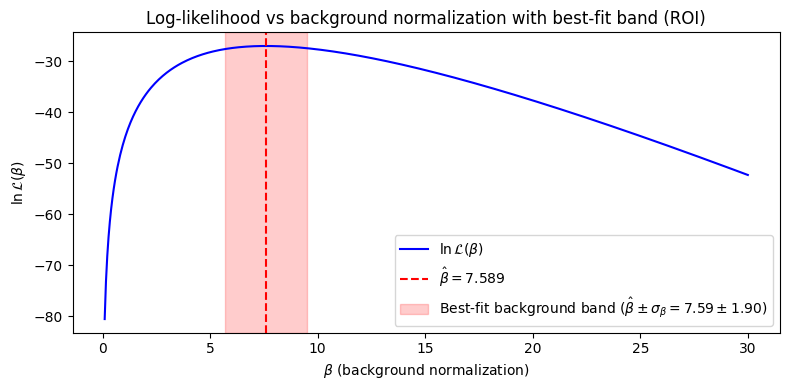

In [414]:
# Log-likelihood vs β with best-fit background band (±1σ shaded)
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(beta_values, log_likes, color='blue', label=r'$\ln\mathcal{L}(\beta)$')
ax.axvline(beta_hat, color='red', linestyle='--', label=rf'$\hat\beta = {beta_hat:.3f}$')
ax.axvspan(beta_hat - sigma_beta, beta_hat + sigma_beta,
           alpha=0.2, color='red',
           label=rf'Best-fit background band ($\hat\beta \pm \sigma_\beta = {beta_hat:.2f} \pm {sigma_beta:.2f}$)')
ax.set_xlabel(r'$\beta$ (background normalization)')
ax.set_ylabel(r'$\ln\mathcal{L}(\beta)$')
ax.set_title('Log-likelihood vs background normalization with best-fit band (ROI)')
ax.legend()
plt.tight_layout()
plt.savefig('../plots/loglikelihood_background_band.png', dpi=150, bbox_inches='tight')
plt.show()

Now, do actually implement the check with the signal test. Luckily, most of the work was done earlier, so just implementing the variable $\mu_s$ and defining the a new log likelihood changes this.

In [ ]:
# Extend background-only likelihood to include signal component
# Reuses: roi_mask, b_nominal, s_i, k_obs, beta_values all defined above

mu_s = 10  # signal strength parameter, tweak to see different results!

def log_likelihood_full(beta, mu_s=mu_s):
    expected = beta * b_nominal.values[roi_mask] + mu_s * s_i[roi_mask]
    expected = np.clip(expected, 1e-12, None)
    return -np.sum(stats.poisson.logpmf(k_obs[roi_mask], expected))

result_full = minimize_scalar(lambda b: log_likelihood_full(b, mu_s),
                              bounds=(0.1, 30.0), method='bounded')
beta_hat_full = result_full.x

# Overlay signal+background log-likelihood on the existing beta scan
log_likes_full = [-log_likelihood_full(b, mu_s) for b in beta_values]

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(beta_values, log_likes,       color='blue',   label='Background only')
ax.plot(beta_values, log_likes_full,  color='orange', label=f'Signal + background (μ_s={mu_s})')
ax.axvline(beta_hat,      color='red',        linestyle='--', label=f'β̂ (bg only) = {beta_hat:.3f}')
ax.axvline(beta_hat_full, color='darkorange', linestyle='--', label=f'β̂ (signal+bg) = {beta_hat_full:.3f}')
ax.set_xlabel('β (background normalization)')
ax.set_ylabel('log L(β)')
ax.set_title(f'Log-likelihood vs β within ROI (μ_s = {mu_s})')
ax.legend()
plt.tight_layout()
plt.savefig('../plots/loglikelihood_signal_vs_background.png', dpi=150, bbox_inches='tight')
plt.show()